In [84]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline

In [85]:
df=pd.read_csv('Diabetes Missing Data.csv')

In [86]:
df.sample(5)

,Pregnant,Glucose,Diastolic_BP,Skin_Fold,Serum_Insulin,BMI,Diabetes_Pedigree,Age,Class
233,4,122.0,68.0,NaN,NaN,35.0,0.394,29,0
663,9,145.0,80.0,46.0,130.0,37.9,0.637,40,1
278,5,114.0,74.0,NaN,NaN,24.9,0.744,57,0
255,1,113.0,64.0,35.0,NaN,33.6,0.543,21,1
510,12,84.0,72.0,31.0,NaN,29.7,0.297,46,1


In [87]:
df.shape

(768, 9)

In [88]:
df.isnull().sum()

Pregnant               0
Glucose                5
Diastolic_BP          35
Skin_Fold            227
Serum_Insulin        374
BMI                   11
Diabetes_Pedigree      0
Age                    0
Class                  0
dtype: int64

In [89]:
df.dtypes

Pregnant               int64
Glucose              float64
Diastolic_BP         float64
Skin_Fold            float64
Serum_Insulin        float64
BMI                  float64
Diabetes_Pedigree    float64
Age                    int64
Class                  int64
dtype: object

In [90]:
df.columns = df.columns.str.strip()

I WILL FILL EVERY COLUMN WITH ITS MEAN BUT DROP SERUM INSULIN AND SKIN FOLD COLUMN

In [91]:
column=[i for i in df.columns if i!='Serum_Insulin' and i!='Skin_Fold' and i!='Class']

In [92]:
column

['Pregnant', 'Glucose', 'Diastolic_BP', 'BMI', 'Diabetes_Pedigree', 'Age']

In [93]:
df.drop(['Serum_Insulin','Skin_Fold'], axis=1, inplace=True)

In [94]:
df.sample(5)

,Pregnant,Glucose,Diastolic_BP,BMI,Diabetes_Pedigree,Age,Class
175,8,179.0,72.0,32.7,0.719,36,1
106,1,96.0,122.0,22.4,0.207,27,0
617,2,68.0,62.0,20.1,0.257,23,0
465,0,124.0,56.0,21.8,0.452,21,0
372,0,84.0,64.0,35.8,0.545,21,0


In [95]:
df.fillna(df.mean(), inplace=True)

In [96]:
df.isnull().sum()

Pregnant             0
Glucose              0
Diastolic_BP         0
BMI                  0
Diabetes_Pedigree    0
Age                  0
Class                0
dtype: int64

DATA CLEANING DONE NOW EDA STARTS

<Axes: >

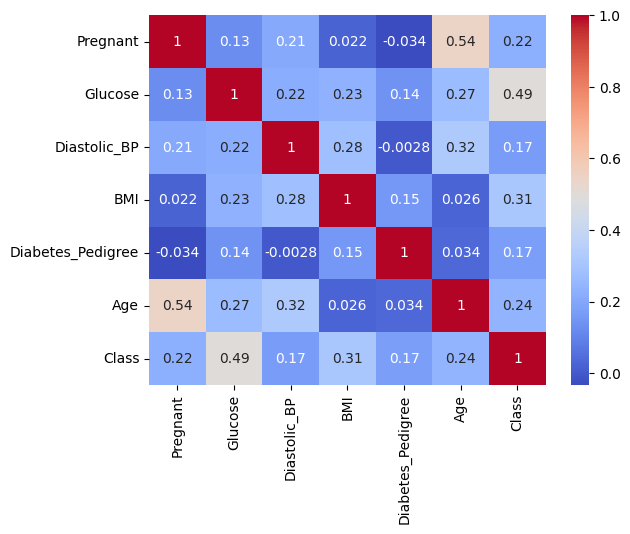

In [97]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

NO COLUMN HAS AN INTERCORRELATION MORE THAN .54 SO THERE IS NO NEED TO DROP ANY MORE COLUMNS

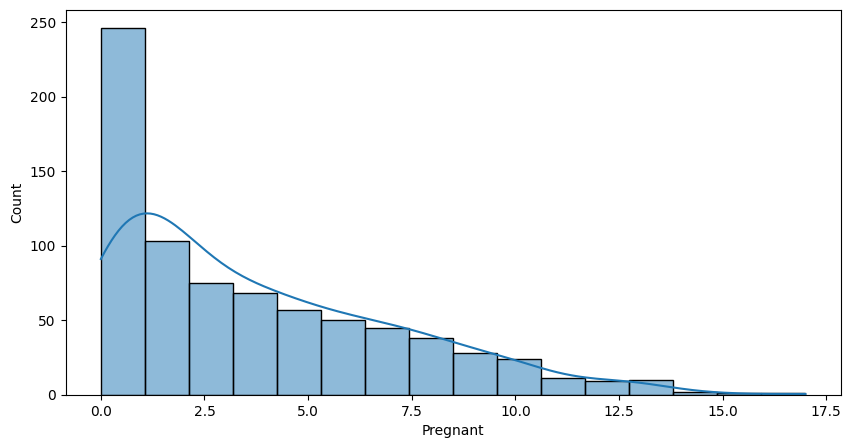

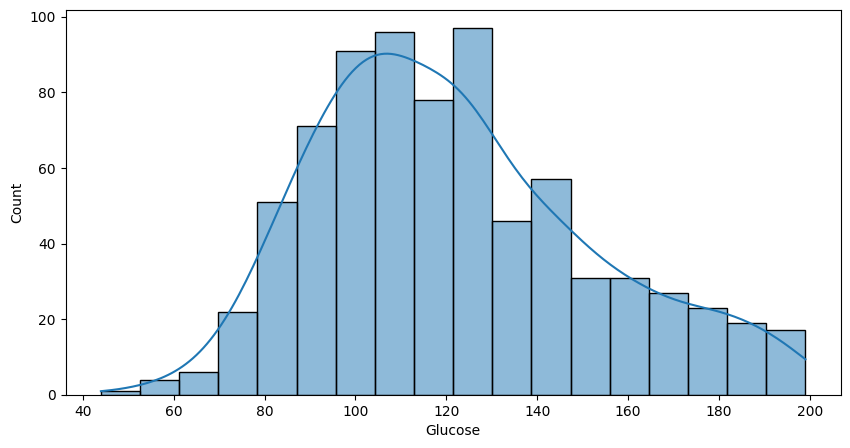

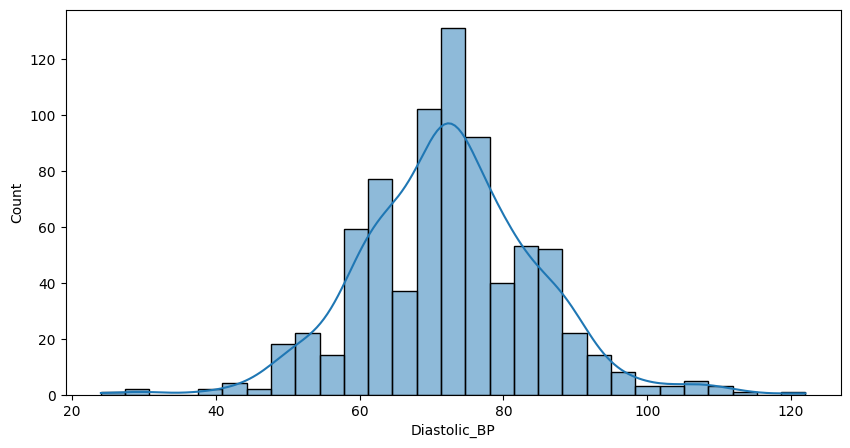

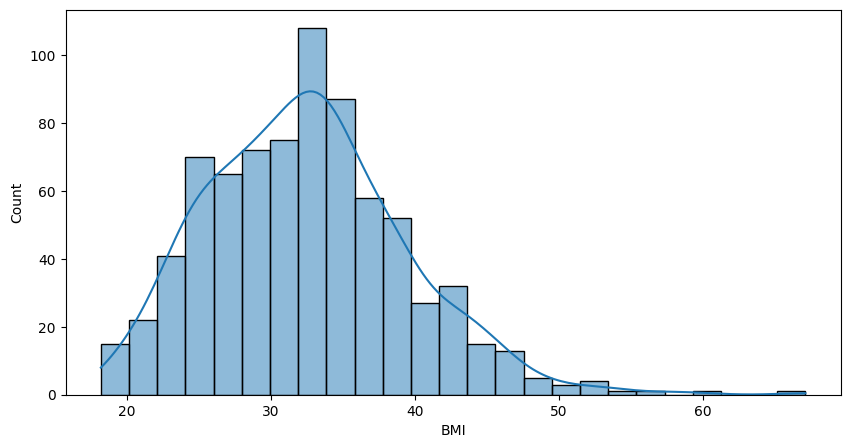

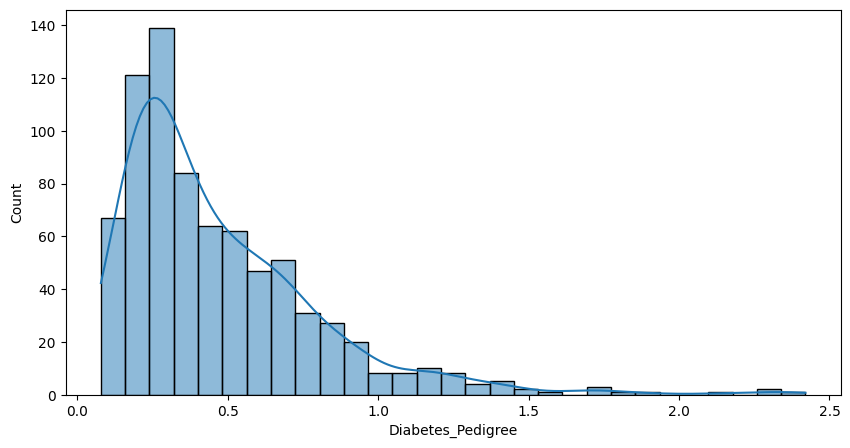

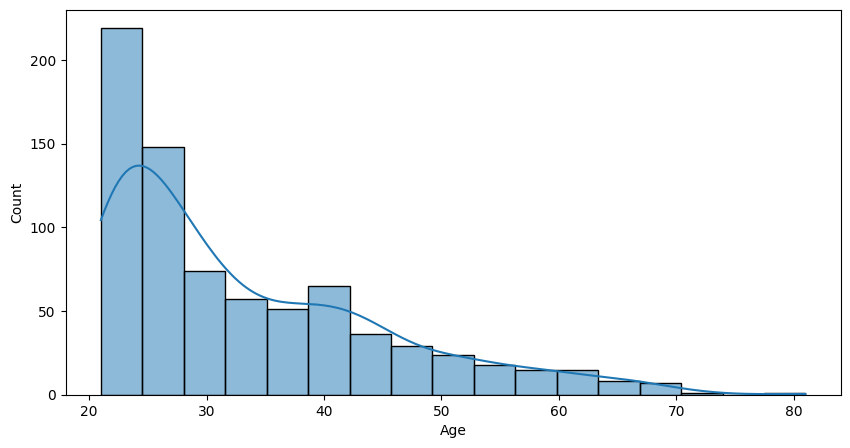

In [98]:
for i in column:
    plt.figure(figsize=(10,5))
    sns.histplot(df[i], kde=True)

BOX PLOTS OF EACH COLUMNS

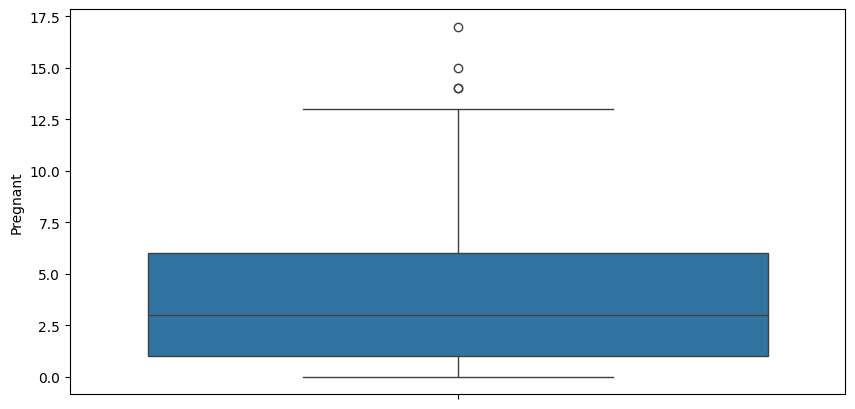

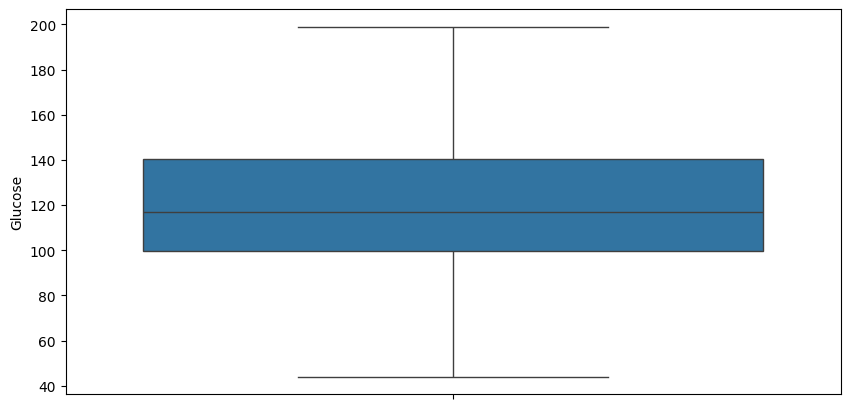

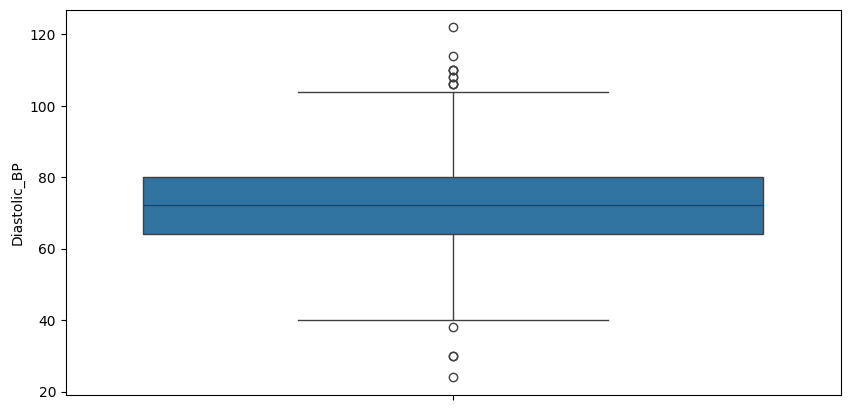

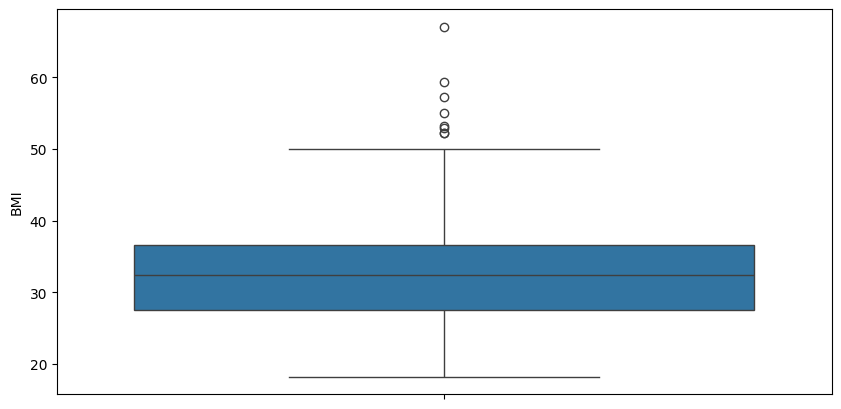

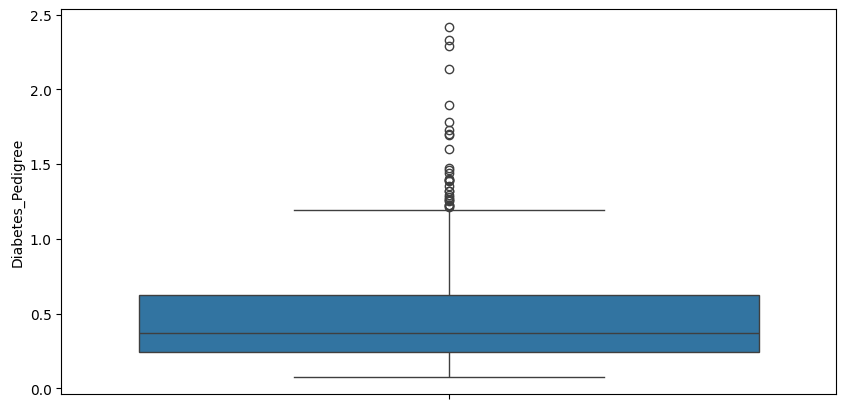

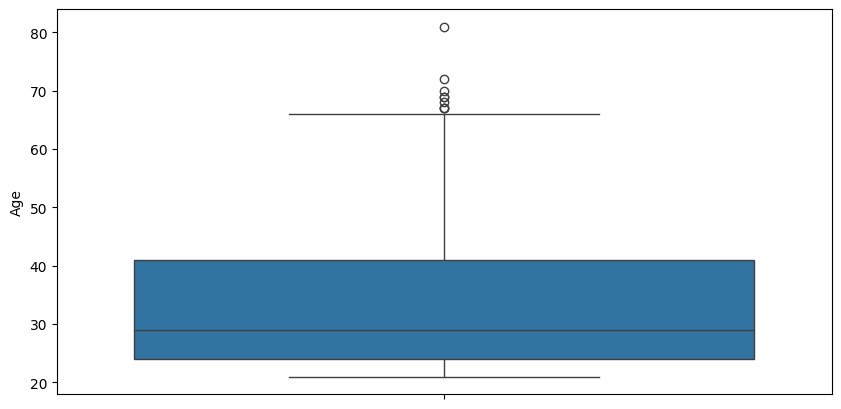

In [99]:
for i in column:
    plt.figure(figsize=(10,5))
    sns.boxplot(df[i])

REMOVING THE OUTLIERS

In [100]:
def remove_outliers(df, columns, multiplier=1.5):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - (multiplier * IQR)
        upper_bound = Q3 + (multiplier * IQR)
        # Filter rows where the column value is within bounds
        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean

In [101]:
df=remove_outliers(df, column)

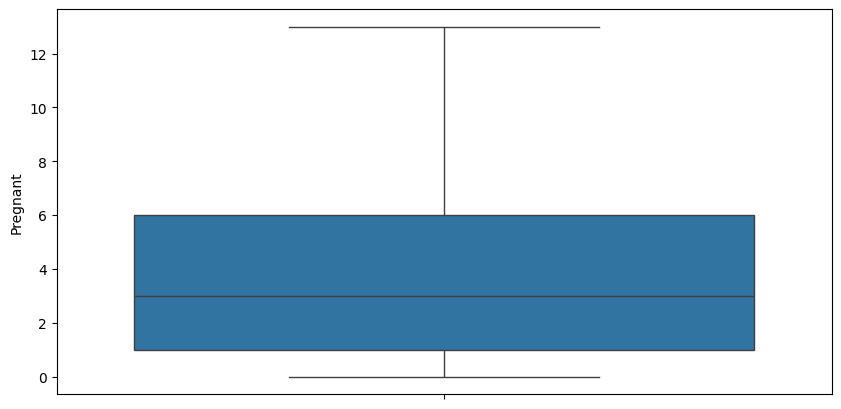

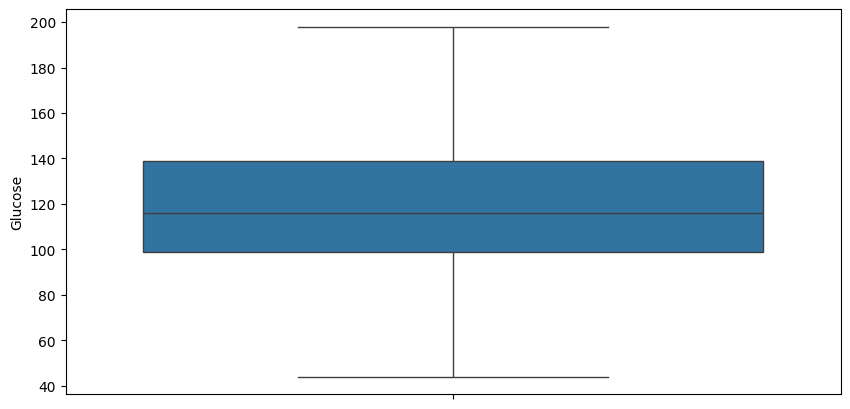

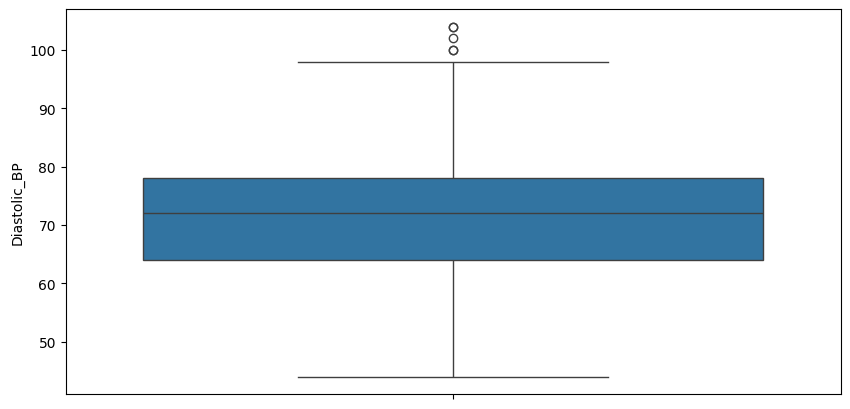

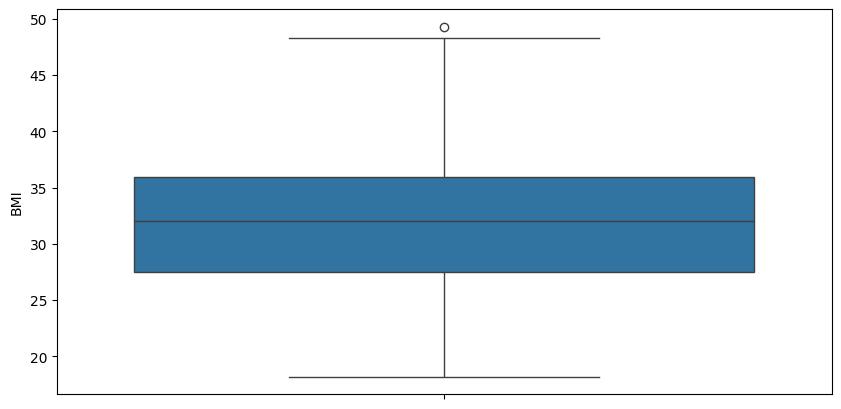

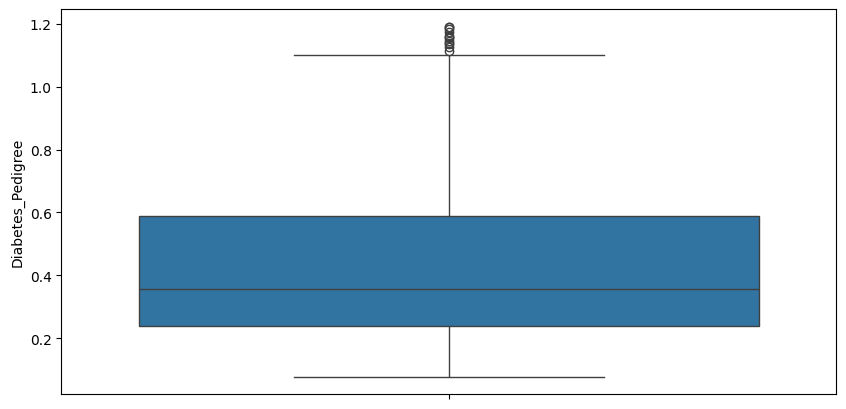

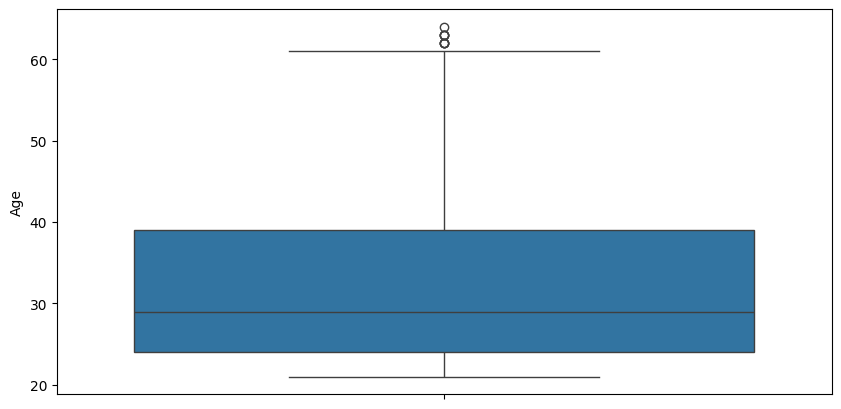

In [102]:
for i in column:
    plt.figure(figsize=(10,5))
    sns.boxplot(df[i])

NOW DATA IS COMPLETELY CLEANED

In [103]:
from scipy.stats import shapiro
for i in column:
    stat, p = shapiro(df[i])
    print(f'Statistics={stat}, p={p}')
    alpha = 0.05
    if p > alpha:
        print(f'{i} looks Gaussian (fail to reject H0)')
    else:
        print(f'{i} does not look Gaussian (reject H0)')

Statistics=0.9059967680934081, p=2.5677794784621866e-20
Pregnant does not look Gaussian (reject H0)
Statistics=0.9676932846518509, p=2.7684849613796174e-11
Glucose does not look Gaussian (reject H0)
Statistics=0.9946750218524647, p=0.015470260485790614
Diastolic_BP does not look Gaussian (reject H0)
Statistics=0.9906550176348665, p=0.0002079170277399218
BMI does not look Gaussian (reject H0)
Statistics=0.9171736214317562, p=4.2848495333125523e-19
Diabetes_Pedigree does not look Gaussian (reject H0)
Statistics=0.8801489993241849, p=8.892423713809122e-23
Age does not look Gaussian (reject H0)


NO COLUMN IS NORMALLY DISTRIBUTED SO WE NEED TO MAKE IT NORMAL

In [104]:
df.to_csv('Diabetes Cleaned Data.csv', index=False)